# STEP - 1: Grain structure generation

This step generates the initial Monte-Carlo grain structure using the UPXO `mcgs` engine, then detects grains and computes key 2D morphology descriptors (area, perimeter, aspect ratio, etc.) needed for downstream geometrification and meshing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.ggrowth.mcgs import mcgs

In [2]:
pxt = mcgs(input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\confMesh\\confMesh1.xls')
pxt.simulate()
pxt.detect_grains(library='cc3d', connectivity=4)

tslice = list(pxt.gs.keys())[-1]
# tslice = 5

gstslice = pxt.gs[tslice]
gstslice.char_morph_2d(bbox=True, use_version=2, bbox_ex=True, npixels=False,
                npixels_gb=False, area=True, eq_diameter=True,
                perimeter=True, perimeter_crofton=True,
                compactness=True, gb_length_px=False,
                aspect_ratio=True,
                solidity=True, morph_ori=False,
                circularity=False,
                eccentricity=False, feret_diameter=True,
                major_axis_length=False, minor_axis_length=False,
                euler_number=False, append=False, saa=True,
                throw=False, char_grain_positions=False,
                find_neigh=False, char_gb=True,
                make_skim_prop=True, get_grain_coords=False)
gstslice.find_neigh()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 10
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored


# STEP - 2: Convert pixelated GS to geometric GS

This step converts the pixelated grain structure (`gstslice`) into a geometric representation using `polygonised_grain_structure`. The resulting polygons and grain-boundary segments are required for smoothing, meshing, and exporting.

The process includes the followinh:

- Instantiate `polygonised_grain_structure` with `gstslice.lgi`, `gstslice.gid`, and `gstslice.neigh_gid`.
- Parse the labeled grid and grain adjacency to build per-grain polygonal boundaries.
- Convert pixel/voxel boundaries to geometric entities via `pix_to_geom()`.
- Populate geometric containers (grain polygons and GB segments) in `geomGS`.
- Store the resulting geometric polyxtal for downstream smoothing and meshing.

In [3]:
from upxo.pxtal.geometrification import polygonised_grain_structure

In [4]:
geomGS = polygonised_grain_structure(gstslice.lgi, gstslice.gid, gstslice.neigh_gid)

The next step has a lot of details. But, the following information should be enough to make you awar eof the process. 

`geomGS.pix_to_geom(verbose=False)` takes the pixel/voxel boundaries implied by `gstslice.lgi` and the neighbor graph `gstslice.neigh_gid`, then constructs polygonal grain boundaries and grain polygons for the **geometric grain structure** stored in `geomGS`.

Key details and behaviors to note:

- **Inputs already embedded in `geomGS`**  
    The method operates on data passed at construction:  
    - `lgi` (labeled grain image / state map)  
    - `gid` (grain IDs)  
    - `neigh_gid` (grain adjacency list)

- **Boundary extraction from pixel topology**  
    The method extracts pixel boundaries on the labeled grid to build per-grain boundary point sequences, using sub-pixel determination. This is not a “single polygon” per grain at first; it often starts as **multiple boundary segments** that are then ordered and stitched intyernally to gvie a morphologically consistent polygon.

- **Neighbor-aware segmentation**  
    Grain boundary segments are typically associated with *pairs of grain IDs* (a boundary belongs to grain A–B). This is essential later for GB-conformant meshing and for maintaining grain boundary ownership consistency.

- **Pixel → geometric conversion**  
    Each boundary sequence is converted from **pixel indices** to **physical coordinates** (respecting `uigrid` bounds and pixel size). This ensures the geometric output is in the same coordinate system used by smoothing and meshing.

- **Population of geometric containers**  
    `pix_to_geom()` populates at least these core structures inside `geomGS`:
    - **`POLYXTAL`**: per-grain polygons (grain interiors)
    - **`GB`**: grain-boundary segments (linework per grain pair)
    These are the exact structures consumed by `smooth_gbsegs()` and `confMesh2d.from_geometric_pxtal()`.

- **Small but important checks**  
    Expect internal logic to:
    - **Remove duplicate points** along boundaries
    - **Ensure closed loops** for each grain polygon
    - **Handle boundary grains** (grains touching the outer domain edge)
    - **Preserve ordering** for proper polygon orientation and GB continuity

- **Verbose flag**  
    `verbose=False` suppresses tracing/log output. When debugging topology or missing polygons, enabling verbosity is useful to check how many grains/segments were generated and whether any were skipped due to invalid geometry.


In [63]:
geomGS.pix_to_geom(verbose=False, perform_xtal_dict_check=True)


c:\Users\rg5749\AppData\Local\anaconda3\envs\UPXO313a\Lib\site-packages\rasterio\io.py:143: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  rd = writer(


In [65]:
dir(geomGS)

['AssembleGBSEGS',
 'EPS_coord_coincide',
 'GB',
 'GBCoords',
 'GBP',
 'GBPOINTS',
 'GBP_at_boundary',
 'GBP_pure',
 'GBSEG',
 'GBSEGMENTS',
 'GRAINS',
 'JNP',
 'POLYXTAL',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 'align_gbmullines_start_to_jnp_start',
 'allpol',
 'are_grains_closed_usecoords',
 'are_grains_closed_usenodes',
 'area_gid',
 'arrange_junction_point_coords_new',
 'assess_mesh_quality',
 'build_all_gbp_objects',
 'build_gbmullines_grain_wise',
 'build_gbp_grain_wise_indices_coordbased',
 'build_gbp_grain_wise_indices_geometric',
 'build_gbp_grain_wise_indices_pointsbased',
 'build_jnp_grain_wise_indices

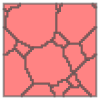

In [67]:
geomGS.gsmp['raw']

# STEP - 3: Perform grain boundary smoothing

This step refines the **polygonal grain-boundary network** created in the previous stage into a smoother, more mesh-friendly geometry. The raw polygonization can contain stair-stepped edges and short segments inherited from the pixel grid; smoothing reduces these artifacts while preserving topology and grain adjacency.

**What happens conceptually:**

- **Input geometry**  
    The method operates on `geomGS.GB` and `geomGS.POLYXTAL`, which contain:
    - Grain boundary segments (GBs) as linework grouped by grain pairs
    - Grain polygons defining each grain interior

- **Smoothing passes**  
    A multi-pass strategy is used (`npasses`) to iteratively smooth boundaries. Each pass:
    - Replaces sharp, pixel-induced corners with locally averaged segments
    - Preserves grain connectivity and boundary ownership (no grain merges/splits)

- **Minimum segment length control**  
    `min_segment_length_factor` sets a cap on how aggressively short segments are removed or merged.  
    Higher values enforce coarser, cleaner boundaries; lower values preserve fine detail.

- **Output containers**  
    Smoothed results are stored in:
    - `geomGS.smoothed[gsname]['GB']`
    - `geomGS.smoothed[gsname]['POLYXTAL']`
    allowing direct comparison against the original geometry and selection for meshing.

- **Why it matters**  
    Smoothing improves:
    - **Meshing stability** (fewer tiny edges, better element quality)
    - **Topology consistency** (cleaner intersection handling)
    - **Geometric fidelity** in downstream analysis and export

The plots that follow compare the **original** vs **smoothed** polygonal grain structure side-by-side, confirming that the smoothing improves boundary quality without altering the overall grain layout.

In [6]:
npasses = 2
min_segment_length_factor = 2
gsname = 'gs.'+str(npasses)+'passes.'+ str(min_segment_length_factor) + 'minseglenfactor'
geomGS.smooth_gbsegs(geomGS.GB, npasses=npasses,
                max_smooth_levels=np.repeat(min_segment_length_factor, npasses),
                plot=False, name=gsname)
geomGS.smoothed.keys()

Assembling grain boundary segments into grain boundary multi-linestrings
Carrying out smoothing pass: 1
Carrying out smoothing pass: 2


dict_keys(['gs.2passes.2minseglenfactor'])

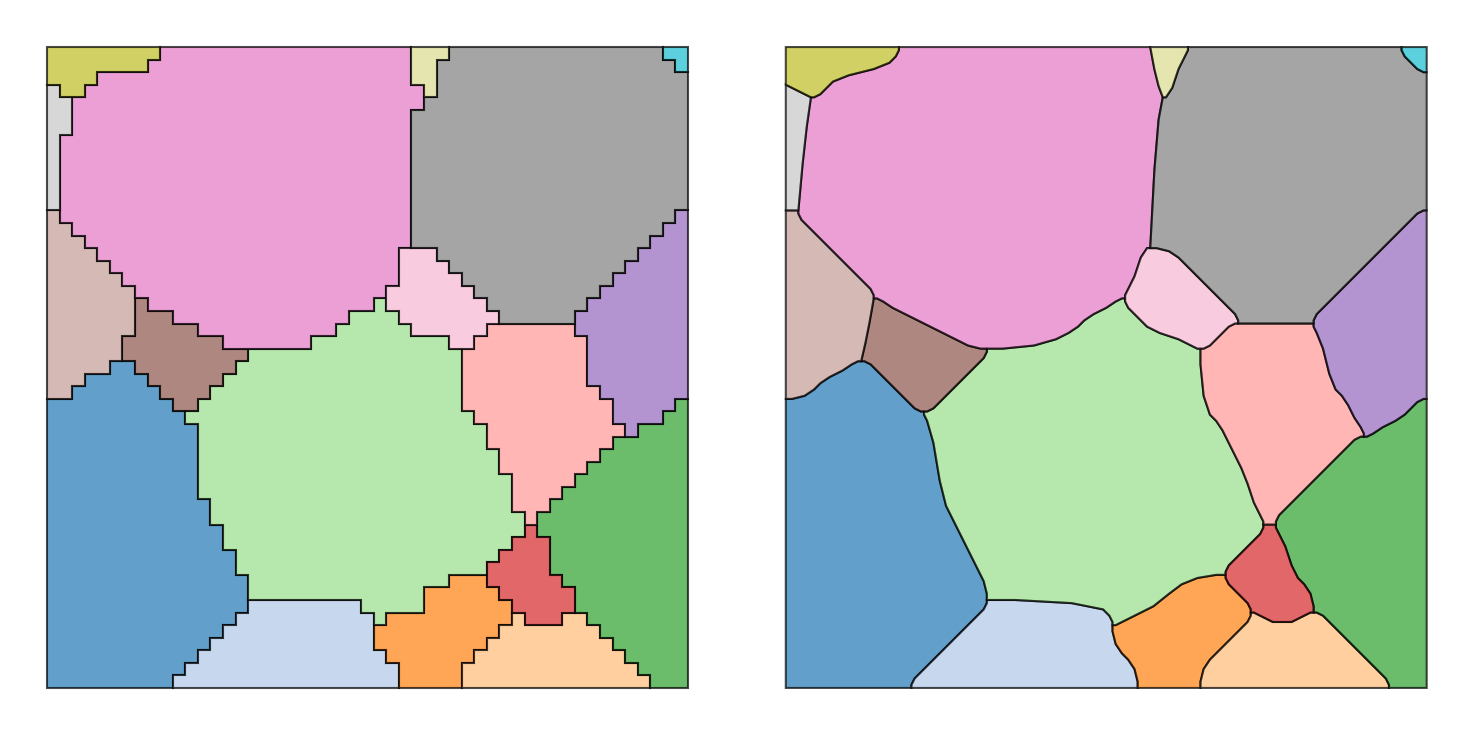

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)

geomGS.plotgs(geomGS.POLYXTAL, fig=fig, ax=axes[0])
axes[0].set_axis_off()

geomGS.plotgs(geomGS.smoothed[gsname]['POLYXTAL'], fig=fig, ax=axes[1], cmap='tab20')
axes[1].set_axis_off()

plt.tight_layout()

# STEP - 4: Grain boundary conformant finite element meshing

In [8]:
from upxo.meshing.conformal_mesher2d import confMesh2d

`confMesh2d.from_geometric_pxtal` initializes a grain-boundary–conformant 2D mesh from the geometric polyxtal created during polygonization and smoothing. It consumes the smoothed per-grain polygons (e.g., `geomGS.smoothed[gsname]['POLYXTAL']`) and the domain bounds to build the meshing-ready geometric tessellation. This step bridges the geometric grain structure to downstream FE meshing, ensuring grain boundaries are preserved as mesh features.

In [9]:
gsConfMesh = confMesh2d.from_geometric_pxtal(gsgen_method='shapely_pxtal_load',
                pxtal=geomGS.smoothed[gsname]['POLYXTAL'],
                xbound=[gstslice.uigrid.xmin, gstslice.uigrid.xmax],
                ybound=[gstslice.uigrid.ymin, gstslice.uigrid.ymax])

In [10]:
gsConfMesh.set_fids(gsConfMesh.gtess.L0.pxtal.geoms)

## Introduction to `femesh_pygmsh`

`gsConfMesh.femesh_pygmsh(...)` generates a grain-boundary–conformant finite element mesh from the geometric tessellation built in earlier steps. It uses **pygmsh/Gmsh** to create quad/tri elements while respecting grain boundaries as mesh features. The method supports key controls such as:

- **`elementShape` / `elementOrder`**: element topology and polynomial order  
- **`meshingAlgorithmID`**: Gmsh meshing algorithm selector  
- **`elsize_global`**: global target element size  
- **Intermediate outputs**: VTK export

After meshing, the workflow calls `filter_mesh()` and `get_mesh_geometry()` to obtain clean connectivity arrays (`P, L, T, Q`) for visualization, quality checks, and downstream export.Here, `P, L, T, Q` respectively stand for **Points**, **Lines**, **Triangles** and **Quads**.

In [11]:
gsConfMesh.femesh_pygmsh(elementShape='quad', elementOrder=1, 
                meshingAlgorithmID=4, elsize_global=[1.0],
                intermediateFilename='femesh',
                intermediateFileformat='vtk')

meshing pxtal.get_L0_ng()
----------------------------------------
PXTAL with 18 xtals: meshing success 
     Dimensionality = 2 
     Element order = 1 
     Algorithm = 4 
----------------------------------------


In [12]:
gsConfMesh.filter_mesh()

 #### p: points, l: linse, t: trianglse, q: quads

In [13]:
P, L, T, Q = gsConfMesh.get_mesh_geometry()

In [14]:
cellTypes = [c.type for c in gsConfMesh.filtered_mesh.cells]
cellTypes
cellTypeLoc = {cellType: i for i, cellType in enumerate(cellTypes)}
cellTypeLoc

{'line': 0, 'triangle': 1, 'quad': 2}

`P, L, T, Q` could alternatively also be obtained as below, using the underlying data.

In [15]:
points_2d = gsConfMesh.filtered_mesh.points[:, :2]
lines = gsConfMesh.filtered_mesh.cells[cellTypeLoc['line']].data if 'line' in cellTypes else None
triangles = gsConfMesh.filtered_mesh.cells[cellTypeLoc['triangle']].data if 'triangle' in cellTypes else None
quads = gsConfMesh.filtered_mesh.cells[cellTypeLoc['quad']].data if 'quad' in cellTypes else None

In [16]:
visualize = True

In [17]:
"""
if visualize:
    # Example 1: Basic visualization with nodes and statistics
    fig, ax = gsConfMesh.see_femesh(points_2d, lines, triangles, quads,
                        figsize=(8, 8), dpi=50,
                        show_nodes=False, node_size=1,
                        show_stats=False, stats_loc='upper left')
plt.show()
"""

"""if visualize:
    # Example 2: Display element numbers (useful for debugging)
    fig, ax = see_femesh(points_2d, lines, triangles, quads,
                        figsize=(10, 10), dpi=50,
                        show_elem_numbers=True,
                        elem_number_fontsize=6,
                        show_stats=False,
                        show_legend=False)
    plt.show()
"""

"""if visualize:
    # Example 3: Custom styling - different colors for tris vs quads
    fig, ax = see_femesh(points_2d, lines, triangles, quads,
                        figsize=(8, 8), dpi=50,
                        tri_edgecolor='red', tri_linewidth=0.8,
                        quad_edgecolor='blue', quad_linewidth=0.5,
                        line_color='purple', line_linewidth=3.0,
                        show_legend=True, show_stats=True,
                        title='Mesh with Custom Colors')
    plt.show()
"""

"if visualize:\n    # Example 3: Custom styling - different colors for tris vs quads\n    fig, ax = see_femesh(points_2d, lines, triangles, quads,\n                        figsize=(8, 8), dpi=50,\n                        tri_edgecolor='red', tri_linewidth=0.8,\n                        quad_edgecolor='blue', quad_linewidth=0.5,\n                        line_color='purple', line_linewidth=3.0,\n                        show_legend=True, show_stats=True,\n                        title='Mesh with Custom Colors')\n    plt.show()\n"

Mesh quality is assessed using `gsConfMesh.assess_quality(...)`, which returns `mqm_data` (per-metric mesh objects) and `mqm_dataframe` (tabular metrics per element). Typical measures include `aspect_ratio`, `skew`, `min_angle`, and `area`, enabling quick screening of element distortion and suitability for downstream analysis. 

*NOTE: This feature is open for contribution. Expected outcome would be to calculat more metrics, other than what is alrealdy internally available / accessible through `assess_quality` definition.*

In [18]:
mqm_data, mqm_dataframe = gsConfMesh.assess_quality(qualityMeasures=['aspect_ratio', 'skew', 'min_angle', 'area'])

c:\Users\rg5749\AppData\Local\anaconda3\envs\UPXO313a\Lib\site-packages\pyvista\core\filters\data_set.py:5650: PyVistaDeprecationWarning: This filter is deprecated. Use `cell_quality` instead. Note that this
new filter does not include an array named ``'CellQuality'`
  warnings.warn(msg, PyVistaDeprecationWarning)


In [19]:
# Example 4: Color by element quality (if available from mqm_dataframe)
# Extract aspect ratio quality data
visualize = False
if visualize:
    if 'mqm_dataframe' in dir():
        quality_values = mqm_dataframe['aspect_ratio'].values
        fig, ax = gsConfMesh.see_femesh(P, L, T, Q, figsize=(5, 3), dpi=50,
                        colorby_quality='all', show_stats=False,
                        quality_data=quality_values, cmap='coolwarm', clim=[1.0, 5.0], 
                        show_colorbar=True, colorbar_label='Aspect Ratio',
                        tri_edgecolor='k', tri_linewidth=0.3, quad_edgecolor='k',
                        quad_linewidth=0.3, show_legend=False, show_axis=True,
                        title='Mesh Colored by Aspect Ratio')
        plt.show()
    else:
        print("mqm_dataframe not found. Run mesh quality assessment first.")


### Attributes and data structures

In [20]:
gsConfMesh.gtess

<UPXO: UKAEA Poly-XTAL Operations.vtpolyxtal2d at 0x1a989321be0>

In [21]:
# gsConfMesh.filtered_mesh.points

In [22]:
# gsConfMesh.filtered_mesh.cells

#### Grain boundary lines: nodal connectivity

In [23]:
gsConfMesh.find_meshCellFeatTypes()
gsConfMesh.find_lineFeatLocation()
gsConfMesh.find_GBlines()
gsConfMesh.find_availableFeatures()
gsConfMesh.find_availableElTypes()
gsConfMesh.find_availableElTypeID()
gsConfMesh.build_nodes()
gsConfMesh.rebuild_elConnectivity()
gsConfMesh.form_elsets_elType()

Working with element type: triangle
Working with element type: quad


In [24]:
# gsConfMesh.elsets_eltype

In [25]:
centroid_data = gsConfMesh.get_elCentroids()

In [26]:
gsConfMesh.find_elID_ranges()
gsConfMesh.form_elsets()

Available element types are: ['triangle', 'quad']


In [27]:
gblines = gsConfMesh.extract_gblines_for_grain('grain.1')

In [28]:
gblines_by_grain = gsConfMesh.extract_gblines_grains()

In [29]:
elQual = gsConfMesh.calc_element_qualities(ar=True, saa=False, throw=True)

In [30]:
visualize = False
if visualize:
    gsConfMesh.plot_elements_geometric_grain('grain.2', elsets_eltype=gsConfMesh.elsets_eltype, 
                            elConn=gsConfMesh.elConn, nodes=gsConfMesh.nodes, GBlines=gsConfMesh.GBlines,
                            gblines_by_grain=None, local_view=True, figsize=(5, 5), dpi=25,
                            plot_triangles=True, plot_quads=True, quality_by_eltype=elQual['ar'], cmap='cubehelix_r')

In [31]:
elIDs = gsConfMesh.find_elIDs_by_quality(elQual=elQual, quality_parameter='ar', 
                          elTypes=['triangle', 'quad'], vmin=1.0, vmax=2.5)
visualize = False
if visualize:
    gsConfMesh.plot_elements_by_elIDs(elIDs['quad'], eltype=None, elConn=gsConfMesh.elConn,
                            nodes=gsConfMesh.nodes, GBlines=gsConfMesh.GBlines, fig=None, ax=None,
                            gblines_by_grain=None, local_view=True,
                            figsize=(10, 6), dpi=150,
                            tri_edgecolor='tab:green', quad_edgecolor='tab:blue',
                            elem_linewidth=0.7, gb_linewidth=1.5,
                            quality_by_eltype=elQual['ar'], cmap='gist_earth_r',
                            vmin=None, vmax=None, show_colorbar=True,
                            title='Selected elements. Quality metric: Aspect ratio')

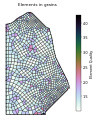

In [ ]:
gsConfMesh.plot_elements_geometric_grains(grain_names=None, grain_ids=gsConfMesh.fids[0], prefix='grain.',
                    elsets_eltype=gsConfMesh.elsets_eltype, elConn=gsConfMesh.elConn, nodes=gsConfMesh.nodes, 
                    GBlines=gsConfMesh.GBlines, fig=None, ax=None, gblines_by_grain=None, local_view=True,
                    figsize=(5, 5), dpi=25, tri_edgecolor='tab:green', quad_edgecolor='tab:blue',
                    elem_linewidth=0.7, gb_linewidth=2.0, plot_triangles=True, plot_quads=True,
                    quality_by_eltype=elQual['ar'], cmap='cubehelix_r', vmin=None, vmax=None, show_colorbar=True)

In [33]:
gbElements = gsConfMesh.collect_gb_elements_for_grains(grain_ids=gsConfMesh.fids)

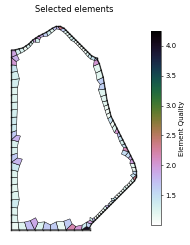

In [ ]:
gsConfMesh.see_gbElements_grains(grain_name='grain.1', eltypes=['triangle', 'quad'], elConn=gsConfMesh.elConn,
            nodes=gsConfMesh.nodes, GBlines=gsConfMesh.GBlines, fig=None, ax=None, gblines_by_grain=None, local_view=True,
            figsize=(5, 5), dpi=50, tri_edgecolor='tab:green', quad_edgecolor='tab:blue', elem_linewidth=0.7, gb_linewidth=2.0,
            quality_by_eltype=elQual['ar'], cmap='cubehelix_r', vmin=None, vmax=None, show_colorbar=True, title='Selected elements')

In [35]:
global_ids_by_type, global_to_local, local_to_global = gsConfMesh.build_global_element_numbering()

In [36]:
sample_quad_ids = np.array([0, 5, 10, 25], dtype=int)
gsConfMesh.find_el_neigh(sample_quad_ids, n_order=1, eltype='quad', include_self=False)

array([  7,  20,  21,  94,  95, 115, 116, 303, 313, 320, 381, 477, 478,
       482, 532, 573, 575, 577, 635, 639, 657, 701, 797, 799, 867, 877,
       878, 894, 912, 913, 926, 933])

In [37]:
gb_elements_subset = gsConfMesh.collect_gb_elements_for_grains(grain_ids=gsConfMesh.fids)

In [ ]:
find_neigh=False
if find_neigh:
        neigh_ordedr = 0
        neighbor_ids_by_type, elem_ids_by_type, combined_ids_by_type = gsConfMesh.find_nthOrderNeigh(neigh_ordedr, gb_elements_subset, include_self=False)

visualize = False
if visualize:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
        for idx, et in enumerate(gsConfMesh.availableElTypes):
                gsConfMesh.plot_elements_by_elIDs(element_ids=combined_ids_by_type.get(et, np.array([], dtype=int)),
                        eltype=et, elConn=gsConfMesh.elConn, nodes=gsConfMesh.nodes, GBlines=gsConfMesh.GBlines,
                        fig=fig, ax=ax, local_view=True, quality_by_eltype=elQual['ar'],
                        cmap='cubehelix_r', show_colorbar=(idx == len(gsConfMesh.availableElTypes) - 1),
                        title=f'GB N({neigh_ordedr}) neighbours' )
        plt.tight_layout()

In [62]:
# centroid_data

In [40]:
# gsConfMesh.extract_gblines_grains()

In [41]:
gbnodeCoords = gsConfMesh.extract_gbnodeCoords_grains()

In [42]:
cellNamePrefix = 'grain'

In [43]:
grainElements = {cellNamePrefix+'.'+str(fid): {} for fid in gsConfMesh.fids}
for elType, cellEl in  gsConfMesh.elsets_eltype.items():
    for cellName, elIDs in cellEl.items():
        grainElements[cellName][elType] = elIDs

In [44]:
grain_elCentroidCoords = {elType: coords for elType, coords in centroid_data['coordinates'].items()}
coordinateData = grain_elCentroidCoords

grainCoordinates = {cellNamePrefix+'.'+str(fid): {} for fid in gsConfMesh.fids}
for cellName, _grainelements_ in grainElements.items():
    for eltype, elIDs in _grainelements_.items():
        elCentroidCoords = coordinateData[eltype]
        if elIDs.size > 0:
            grainCoordinates[cellName][eltype] = elCentroidCoords[elIDs]
        else:
            grainCoordinates[cellName][eltype] = None



In [45]:
import importlib
import upxo.meshing.conformal_mesher2d as cm2d_module

# Ensure latest class behavior is active in current kernel
importlib.reload(cm2d_module)
gsConfMesh.__class__ = cm2d_module.confMesh2d

# Use-case: band-based selection from grain-boundary distances
grain_name = 'grain.11'
bands = [[0.0, 2.0], [2.0, 3.5], [3.5, 7.0], [7.0, 9], [9, 12]]

# eltypes=None: auto-pick all available element types in this grain
# with eltypes=None, this plots all selected types
element_ids_by_band, nearest_dist_by_type, (fig, ax), selected_eltypes = gsConfMesh.select_elements_in_bands(
    grain_name=grain_name, bands=bands, gbnodeCoords=gbnodeCoords,
    grainCoordinates=grainCoordinates, grainElements=grainElements,
    eltypes=None, plot_eltype=None, gblines_by_grain=None, plot=False, 
    band_colours=None, auto_cmap='prism', band_facecolors=False)

print('Selected element types:', selected_eltypes)
for band_key, ids_by_type in element_ids_by_band.items():
    print(f'Band {band_key}:', {etype: len(ids) for etype, ids in ids_by_type.items()})

# element_ids_by_band

Selected element types: ['triangle', 'quad']
Band (0.0, 2.0): {'triangle': 51, 'quad': 147}
Band (2.0, 3.5): {'triangle': 10, 'quad': 25}
Band (3.5, 7.0): {'triangle': 0, 'quad': 0}
Band (7.0, 9): {'triangle': 0, 'quad': 0}
Band (9, 12): {'triangle': 0, 'quad': 0}


(0.0, 3.0) {'quad': 5372, 'triangle': 673}
(3.0, 5.0) {'quad': 1395, 'triangle': 104}
(5.0, 7.0) {'quad': 743, 'triangle': 47}
(7.0, 12.0) {'quad': 482, 'triangle': 26}
(12.0, 50) {'quad': 0, 'triangle': 0}


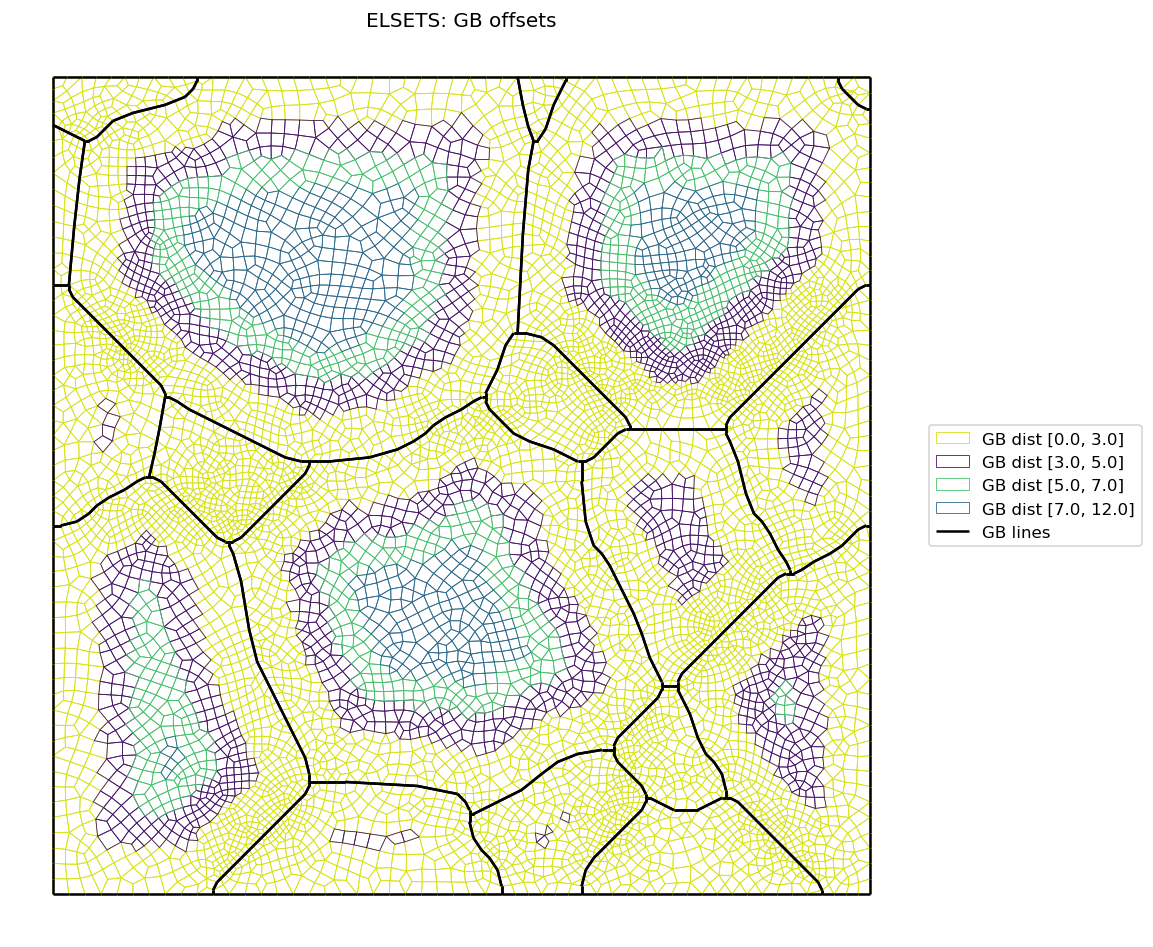

In [ ]:
# AAA
from matplotlib.collections import PolyCollection, LineCollection
from upxo.viz import meshviz

def _collect_selected_polys_by_band(combined_ids_by_band, elConn, nodes, band_colours):
    polys_by_band = {}
    for band_key, ids_by_type in combined_ids_by_band.items():
        band_polys = []
        for etype, elem_ids in ids_by_type.items():
            conn = elConn.get(etype)
            if conn is None or elem_ids is None or len(elem_ids) == 0:
                continue
            valid_ids = np.asarray(elem_ids, dtype=int)
            valid_ids = valid_ids[(valid_ids >= 0) & (valid_ids < len(conn))]
            if valid_ids.size == 0:
                continue
            band_polys.extend([nodes[conn[eid]][:, :2] for eid in valid_ids])
        polys_by_band[band_key] = band_polys
    return polys_by_band

def _plot_band_polys_fast(polys_by_band, gsConfMesh, band_colours, figsize=(8, 8), dpi=120,
                        elem_linewidth=0.7, gb_linewidth=0.7, show_gb_nodes=True, gb_node_color='red',
                        show_gb_lines=True, gb_line_color='k', gb_line_label='GB lines', 
                        legend_prefix='GB dist', title='ELSETS: GB offsets'):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for idx, (band_key, polys) in enumerate(polys_by_band.items()):
        if len(polys) == 0:  # Add one PolyCollection per band
            continue
        band_color = band_colours[idx]
        pc = PolyCollection(polys, facecolors='none', edgecolors=band_color, linewidths=elem_linewidth,
                        alpha=1.0, label=f'{legend_prefix} [{band_key[0]}, {band_key[1]}]')
        ax.add_collection(pc)
    if show_gb_lines and gsConfMesh.GBlines is not None and len(gsConfMesh.GBlines) > 0:
        # Plot all grain-boundary lines once (global view)
        line_verts = gsConfMesh.nodes[gsConfMesh.GBlines][:, :, :2]
        lc = LineCollection(line_verts, colors=gb_line_color, linewidths=gb_linewidth, 
                            alpha=1.0, label=gb_line_label)
        ax.add_collection(lc)

    if show_gb_nodes:
        all_gb = np.vstack([coords[:, :2] for coords in gbnodeCoords.values() if coords is not None and len(coords) > 0])
        ax.scatter(all_gb[:, 0], all_gb[:, 1], s=8, c=gb_node_color, label='GB nodes', zorder=6)

    ax.autoscale()
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_axis_off()
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    return fig, ax

def select_elements_in_bands_all_grains(gsConfMesh, gbnodeCoords, grainCoordinates, grainElements,
                        bands, eltypes=None, auto_cmap='nipy_spectral',
                        band_facecolors=False, plot=True, figsize=(8, 8), dpi=100, 
                        elem_linewidth=0.50, gb_linewidth=1.5, show_gb_nodes=True, gb_node_color='red', 
                        show_gb_lines=False, gb_line_color='k', legend_prefix='GB dist', 
                        title='ELSETS: GB offsets'):
    band_colours = None
    grain_names = sorted(list(grainElements.keys()))
    all_results_by_grain = {}
    combined_ids_by_band = {(min(b), max(b)): {} for b in bands}
    for grain_name in grain_names:
        element_ids_by_band, nearest_dist_by_type, _, selected_eltypes = gsConfMesh.select_elements_in_bands(
                        grain_name=grain_name, bands=bands, gbnodeCoords=gbnodeCoords,
                        grainCoordinates=grainCoordinates, grainElements=grainElements,
                        eltypes=eltypes, plot_eltype=None, gblines_by_grain=None,
                        plot=False, band_colours=band_colours, auto_cmap=auto_cmap,
                        band_facecolors=band_facecolors)
        all_results_by_grain[grain_name] = {'element_ids_by_band': element_ids_by_band,
            'nearest_dist_by_type': nearest_dist_by_type, 'selected_eltypes': selected_eltypes}
        for band_key, ids_by_type in element_ids_by_band.items():
            for etype, ids in ids_by_type.items():
                if etype not in combined_ids_by_band[band_key]:
                    combined_ids_by_band[band_key][etype] = np.array([], dtype=int)
                if ids is not None and len(ids) > 0:
                    combined_ids_by_band[band_key][etype] = np.unique(
                        np.concatenate([combined_ids_by_band[band_key][etype], np.asarray(ids, dtype=int)]) )
    colours_to_use = meshviz.resolve_band_colours(bands, band_colours=band_colours, auto_cmap=auto_cmap)
    fig = ax = None
    if plot:
        polys_by_band = _collect_selected_polys_by_band(combined_ids_by_band, gsConfMesh.elConn,
                                gsConfMesh.nodes, colours_to_use)
        fig, ax = _plot_band_polys_fast(polys_by_band, gsConfMesh, colours_to_use,
                        figsize=figsize, dpi=dpi, elem_linewidth=elem_linewidth, gb_linewidth=gb_linewidth,
                        show_gb_nodes=show_gb_nodes, gb_node_color=gb_node_color,
                        show_gb_lines=show_gb_lines, legend_prefix=legend_prefix, title=title)
    return all_results_by_grain, combined_ids_by_band, (fig, ax)

bands_all = [[0.0, 3.0], [3.0, 5.0], [5.0, 7.0], [7.0, 12.0], [12.0, 50]]
all_results_by_grain, combined_ids_by_band, (fig_all, ax_all) = select_elements_in_bands_all_grains(
                        gsConfMesh=gsConfMesh, gbnodeCoords=gbnodeCoords, grainCoordinates=grainCoordinates,
                        grainElements=grainElements, bands=bands_all, eltypes=None,  auto_cmap='viridis',
                        band_facecolors=False, plot=True, figsize=(12, 8), dpi=120, 
                        elem_linewidth=0.50, gb_linewidth=1.5, show_gb_nodes=False, 
                        gb_node_color='black', show_gb_lines=True, gb_line_color='k',
                        legend_prefix='GB dist', title='ELSETS: GB offsets')
for band_key, ids_by_type in combined_ids_by_band.items():
    print(band_key, {etype: len(ids) for etype, ids in ids_by_type.items()})

In [47]:
gsConfMesh.elConn['quad'][combined_ids_by_band[(0,3)]['quad']]

array([[1393,  701,  702, 1392],
       [1421, 1422, 1424, 1423],
       [1427, 1425, 1428, 1426],
       ...,
       [ 658, 1386, 9127, 9126],
       [9126, 9128, 1384,  657],
       [1387, 9127, 1386,  661]], shape=(5372, 4))

# =============================================================================

In [48]:
gsConfMesh.gtess.write_abapy_input_coords(identification_point_type = 'L0_xtals_reppoints',)

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Coordinate files have been written to parent directory
Please use [UPXO] --> [Abaqus python script] and
      import the VTGS.2d in ABAQUS


# STEP - 3: Querying geometric data in the source object

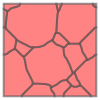

In [49]:
gsConfMesh.gtess.L0.pxtal

In [50]:
gsConfMesh.gtess.find_neighs()




Identifying ALL neighbours


In [51]:
gsConfMesh.gtess.calculate_lengths(level = 0,
                          length_type = 'xtal.polygonal.pbjp'
                          )
gsConfMesh.gtess.L0.xtal_ble_val

[array([ 0.25      ,  0.55901699,  0.70710678,  0.70710678,  0.70710678,
         0.70710678,  0.70710678,  0.70710678,  0.70710678,  0.70710678,
         0.70710678,  0.70710678,  0.70710678,  0.55901699,  0.25      ,
        10.        , 23.        ,  0.5       ,  1.03077641,  0.90138782,
         0.70710678,  0.90138782,  1.11803399,  0.90138782,  0.55901699,
         0.25      ,  0.25      ,  0.55901699,  0.70710678,  0.70710678,
         0.70710678,  0.70710678,  0.70710678,  0.70710678,  0.70710678,
         0.55901699,  0.25      ,  0.25      ,  0.55901699,  1.82002747,
         3.04138127,  2.06155281,  1.11803399,  1.11803399,  1.11803399,
         1.11803399,  1.11803399,  1.11803399,  1.03077641,  0.5       ]),
 array([ 0.25      ,  0.55901699,  0.70710678,  0.70710678,  0.70710678,
         0.70710678,  0.70710678,  0.70710678,  0.70710678,  0.70710678,
         0.70710678,  0.70710678,  0.70710678,  0.55901699,  0.25      ,
        18.        ,  0.5       ,  1.03077641,  0

In [52]:
gsConfMesh.gtess.calculate_areas(area_type = 'polygonal')
gsConfMesh.gtess.L0.xtal_ape_val

array([314.        ,  93.3125    ,  62.        ,  62.375     ,
       176.1875    , 460.9375    ,  32.0625    , 128.4375    ,
       102.8125    ,  47.35185185,  70.46064815, 565.60416667,
        42.25      , 396.41898148,  14.05555556,  22.8125    ,
         7.1087963 ,   2.8125    ])

In [53]:
gsConfMesh.gtess.L0.xtals_n, gsConfMesh.gtess.L0.xtals

(18,
 [<POLYGON ((15.5 6.5, 15.5 6.25, 15.25 5.75, 14.75 5.25, 14.25 4.75, 13.75 4....>,
  <POLYGON ((15.5 6.5, 15.5 6.25, 15.25 5.75, 14.75 5.25, 14.25 4.75, 13.75 4....>,
  <POLYGON ((25.5 4.5, 25.5 4, 25.75 3, 26.25 2.25, 26.75 1.75, 27.25 1, 27.5 ...>,
  <POLYGON ((32.5 -0.5, 32.5 0, 32.75 1, 33.25 1.75, 33.75 2.25, 34.25 2.75, 3...>,
  <POLYGON ((41.5 5.5, 41.75 5.5, 42.25 5.25, 42.75 4.75, 43.25 4.25, 43.75 3....>,
  <POLYGON ((10.5 21.5, 10.5 21.25, 10.75 20.75, 11.25 19, 11.75 16, 12.25 14,...>,
  <POLYGON ((36.5 5.5, 36.5 5.75, 36.25 6.25, 35.75 6.75, 35.25 7.25, 34.75 7....>,
  <POLYGON ((45.5 19.5, 45.25 19.5, 44.75 19.25, 44.25 18.75, 43.75 18.25, 43....>,
  <POLYGON ((50.5 22.5, 50.25 22.5, 49.75 22.25, 49.25 21.75, 48.75 21.25, 48 ...>,
  <POLYGON ((5.5 25.5, 5.75 25.5, 6.25 25.25, 6.75 24.75, 7.25 24.25, 7.75 23....>,
  <POLYGON ((-0.5 22.5, 0 22.5, 1 22.75, 1.75 23.25, 2.25 23.75, 3 24.25, 4 24...>,
  <POLYGON ((26.5 30.5, 26.25 30.5, 25.75 30.25, 25 29.75, 24 29.25, 23

In [54]:
gsConfMesh.gtess.extract_coord(
                      base_data_structure = 'shapely',
                      feature = 'L0_xtals_reppoints',
                      )

In [55]:
repPoints = gsConfMesh.gtess.extract_shapely_coords(shapely_grains_list = None,
                coord_of = 'L0_xtals_reppoints', save_to_attribute = True,
                make_unique = True, throw = True )

In [56]:
centroidPoints = gsConfMesh.gtess.extract_shapely_coords(shapely_grains_list = None,
                coord_of = 'L0_xtals_centroids', save_to_attribute = True,
                make_unique = True, throw = True )

In [57]:
xtal_vertices_pbjp = gsConfMesh.gtess.extract_shapely_coords(shapely_grains_list = None,
                coord_of = 'L0_xtal_vertices_pbjp', save_to_attribute = True,
                make_unique = True, throw = True )[2]

In [58]:
xtal_vertices_pbjp_xtalwise = gsConfMesh.gtess.extract_shapely_coords(shapely_grains_list = None,
                coord_of = 'L0_xtal_vertices_pbjp_xtalwise', save_to_attribute = True,
                make_unique = True, throw = True )

In [59]:
gsConfMesh.gtess.count_number_of_xpbjp(recalculate=True)
gsConfMesh.gtess.L0.n_vert

323

In [60]:
gsConfMesh.gtess.extract_coord(
                      base_data_structure = 'shapely',
                      feature = 'L0_xtals_reppoints',
                      )